In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# PyTorch Dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
# Load data
current_dir = os.getcwd()
path_train = current_dir + "/../dataset/mitbih/" + "mitbih_train.csv"
path_test = current_dir + "/../dataset/mitbih/" + "mitbih_test.csv"

df_train = pd.read_csv(path_train, header=None)
df_test = pd.read_csv(path_test, header=None)

df_train.rename(columns={187:"Class"}, inplace=True)
df_test.rename(columns={187:"Class"}, inplace=True)

print("Dataset after resample")
print("Training set")
print(df_train.shape)
print(df_train["Class"].value_counts())
print("Testing set")
print(df_test.shape)
print(df_test["Class"].value_counts())
#extract class
class_0=df_train[df_train["Class"]==0]
class_1=df_train[df_train["Class"]==1]
class_2=df_train[df_train["Class"]==2]
class_3=df_train[df_train["Class"]==3]
class_4=df_train[df_train["Class"]==4]

class_0_upsample=resample(class_0,replace=True,n_samples=60000,random_state=123)
class_1_upsample=resample(class_1,replace=True,n_samples=20000,random_state=123)
class_2_upsample=resample(class_2,replace=True,n_samples=20000,random_state=124)
class_3_upsample=resample(class_3,replace=True,n_samples=20000,random_state=125)
class_4_upsample=resample(class_4,replace=True,n_samples=20000,random_state=126)

#combine
df_train=pd.concat([class_0_upsample,class_1_upsample,class_2_upsample,class_3_upsample,class_4_upsample])
print("Dataset after resample")
print(df_train.shape)
print(df_train["Class"].value_counts())

# Drop any non-numeric column (like 'Class' from the header row)
df_train = df_train.apply(pd.to_numeric, errors='coerce')
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Remove any NaN values (in case 'Class' was still causing issues)
#df_train = df_train.dropna()
#df_test = df_test.dropna()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Split features and labels
X_train, y_train = df_train.iloc[:, :-1].values, df_train.iloc[:, -1].values
X_test, y_test = df_test.iloc[:, :-1].values, df_test.iloc[:, -1].values

reduction_factor = 0.25  # Keep 25% of the dataset

# Dataloaders
train_valid_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

batch_size = 32
train_size = int(0.8 * len(train_valid_dataset))
val_size = len(train_valid_dataset) - train_size
train_dataset, val_dataset = random_split(train_valid_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Dataset after resample
Training set
(87554, 188)
Class
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64
Testing set
(21892, 188)
Class
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64
Dataset after resample
(140000, 188)
Class
0.0    60000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64


In [4]:
class RCNN(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(RCNN, self).__init__()

        # Define Convolution Layers
        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=6, padding='same')
        self.bn1_1 = nn.BatchNorm1d(32)

        self.conv1_2 = nn.Conv1d(32, 16, 12, padding='same')

        self.residual_1 = nn.Conv1d(1, 16, 6, padding='same')
        self.bn_residual_1 = nn.BatchNorm1d(16)

        self.conv1_3 = nn.Conv1d(32, 32, 16, padding='same')
        self.bn1_3 = nn.BatchNorm1d(32)

        self.conv1_4 = nn.Conv1d(32, 16, 6, padding='same')

        self.residual_2 = nn.Conv1d(32, 16, 6, padding='same')
        self.bn_residual_2 = nn.BatchNorm1d(16)

        self.conv1_5 = nn.Conv1d(32, 32, 6, padding='same')
        self.bn1_5 = nn.BatchNorm1d(32)

        self.conv1_6 = nn.Conv1d(32, 16, 12, padding='same')

        self.residual_3 = nn.Conv1d(32, 16, 6, padding='same')
        self.bn_residual_3 = nn.BatchNorm1d(16)


        # Calculate the output size after convolutions and pooling
        dummy_input = torch.zeros(1, 1, input_size)  # Batch size = 1, channels = 1, input_size = input_size
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()  # Flattened size of the tensor after convolution and pooling

        # Final fully connected layers
        self.fc1 = nn.Linear(flattened_size, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def _forward_convs(self, x):
        # Forward pass through convolutional layers
        x_1 = self.conv1_1(x)
        x_1 = self.bn1_1(x_1)
        x_1 = F.relu(x_1)

        x_2 = self.conv1_2(x_1)
        x_2 = F.relu(x_2)

        residual_1 = self.residual_1(x)
        residual_1 = self.bn_residual_1(residual_1)
        concat_1 = torch.cat((x_2, residual_1), dim=1)
        concat_1 = F.relu(concat_1)
        x_out_1 = F.max_pool1d(concat_1, 6, padding=3)

        x_3 = self.conv1_3(x_out_1)
        x_3 = self.bn1_3(x_3)
        x_3 = F.relu(x_3)

        x_4 = self.conv1_4(x_3)
        x_4 = F.relu(x_4)

        residual_2 = self.residual_2(x_3)
        residual_2 = self.bn_residual_2(residual_2)
        concat_2 = torch.cat((x_4, residual_2), dim=1)
        concat_2 = F.relu(concat_2)
        x_out_2 = F.max_pool1d(concat_2, 6, stride=2, padding=3)

        x_5 = self.conv1_5(x_out_2)
        x_5 = self.bn1_5(x_5)
        x_5 = F.relu(x_5)

        x_6 = self.conv1_6(x_5)
        x_6 = F.relu(x_6)

        residual_3 = self.residual_3(x_5)
        residual_3 = self.bn_residual_3(residual_3)
        concat_3 = torch.cat((x_5, residual_3), dim=1)
        concat_3 = F.relu(concat_3)
        x_out_3 = F.max_pool1d(concat_3, 6, padding=3)
        return x_out_3

    def forward(self, x):
        # Use the _forward_convs function for convolutional layers
        x = self._forward_convs(x)

        # Flatten the output from convolution layers before passing to fully connected layers
        flat = x.view(x.size(0), -1)
        x = self.fc1(flat)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)

        return x


In [5]:
model = RCNN().to(device)
print(device)
print(model)
criterion = nn.CrossEntropyLoss(reduction='mean')
loss_fn = criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


cuda
RCNN(
  (conv1_1): Conv1d(1, 32, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv1d(32, 16, kernel_size=(12,), stride=(1,), padding=same)
  (residual_1): Conv1d(1, 16, kernel_size=(6,), stride=(1,), padding=same)
  (bn_residual_1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_3): Conv1d(32, 32, kernel_size=(16,), stride=(1,), padding=same)
  (bn1_3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_4): Conv1d(32, 16, kernel_size=(6,), stride=(1,), padding=same)
  (residual_2): Conv1d(32, 16, kernel_size=(6,), stride=(1,), padding=same)
  (bn_residual_2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_5): Conv1d(32, 32, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [6]:
path = "models_save/"
model_path_load = path + "CNN_Resnet_original.pth"
model.load_state_dict(torch.load(model_path_load))

<All keys matched successfully>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def performance_evaluation(model, data_loader, labels_mapping, message_banner=""):
    model.eval()
    y_pred, y_true = [], []
    
    # Calculate predictions and true labels
    with torch.no_grad():
        for inputs, labels in data_loader:  # Replace test_loader with data_loader
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    
    # Print classification report
    print(message_banner)
    print(classification_report(y_true, y_pred))

    # Generate classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize to get percentages

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm_normalized, annot=False, fmt=".2f", cmap="Blues", 
                     xticklabels=labels_mapping, yticklabels=labels_mapping)

    # Add both number and percentage inside each cell of the confusion matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            
            percentage = cm_normalized[i, j] * 100
            count = cm[i, j]
            if percentage > 50:
                text_color = 'white'
            else:
                text_color = 'black'
                
            # Format: number (percentage%)
            ax.text(j + 0.5, i + 0.5, f'{cm[i, j]}\n({cm_normalized[i, j] * 100:.2f}%)',
                    ha='center', va='center', color=text_color, fontsize=10)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix of Original dataset")
    
    path = "evaluation"
    plt.savefig(f"{path}/confusion_matrix_original_{message_banner}.png", dpi=300, bbox_inches='tight')
    plt.show()
    return report


Test set Valuation
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.92      0.79      0.85       556
           2       0.97      0.96      0.96      1448
           3       0.89      0.73      0.80       162
           4       1.00      0.97      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.95      0.89      0.92     21892
weighted avg       0.99      0.99      0.99     21892



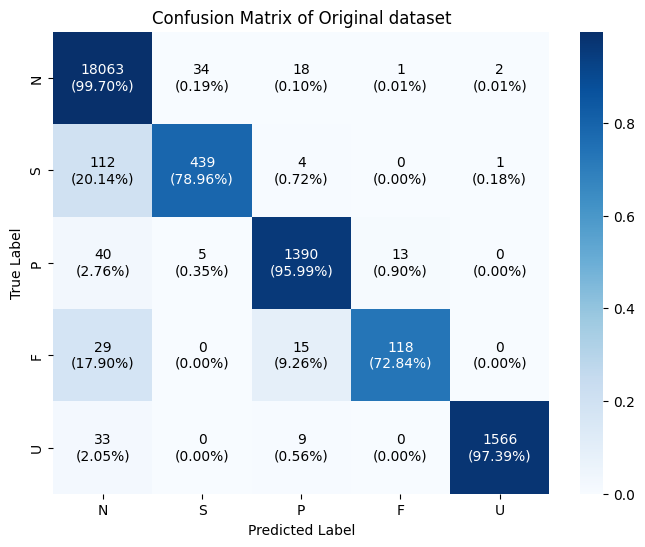

Train set Valuation
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     48018
           1       1.00      0.94      0.97     16053
           2       0.96      0.99      0.98     15948
           3       1.00      0.85      0.92     15967
           4       1.00      0.99      1.00     16014

    accuracy                           0.97    112000
   macro avg       0.98      0.95      0.97    112000
weighted avg       0.97      0.97      0.97    112000



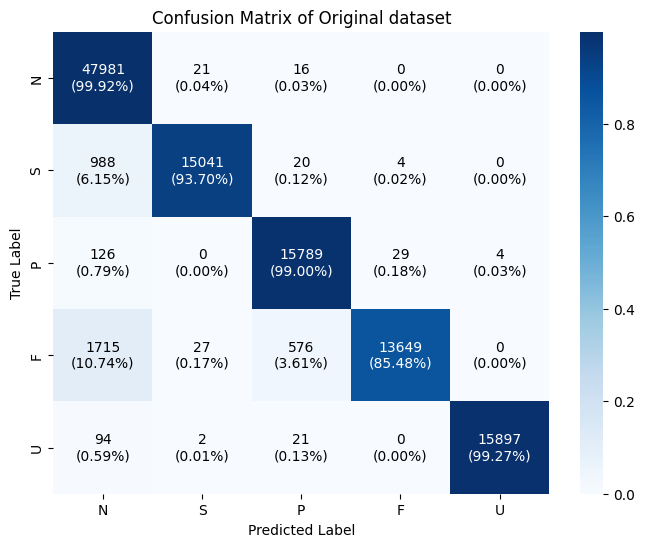

Val set Valuation
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     11982
           1       1.00      0.94      0.97      3947
           2       0.96      0.99      0.97      4052
           3       1.00      0.84      0.91      4033
           4       1.00      0.99      1.00      3986

    accuracy                           0.97     28000
   macro avg       0.98      0.95      0.96     28000
weighted avg       0.97      0.97      0.96     28000



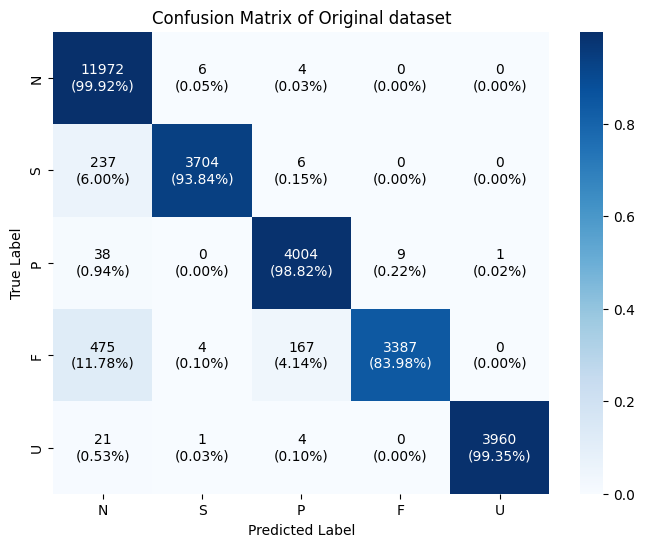

{'0': {'precision': 0.9394961939888566,
  'recall': 0.9991654147888499,
  'f1-score': 0.9684125379170879,
  'support': 11982.0},
 '1': {'precision': 0.9970390309555854,
  'recall': 0.938434253863694,
  'f1-score': 0.9668493865831376,
  'support': 3947.0},
 '2': {'precision': 0.9567502986857825,
  'recall': 0.9881539980256664,
  'f1-score': 0.9721986160009712,
  'support': 4052.0},
 '3': {'precision': 0.9973498233215548,
  'recall': 0.8398214728489958,
  'f1-score': 0.9118320096917486,
  'support': 4033.0},
 '4': {'precision': 0.9997475385003787,
  'recall': 0.9934771700953337,
  'f1-score': 0.9966024915062288,
  'support': 3986.0},
 'accuracy': 0.96525,
 'macro avg': {'precision': 0.9780765770904317,
  'recall': 0.9518104619245079,
  'f1-score': 0.9631790083398348,
  'support': 28000.0},
 'weighted avg': {'precision': 0.9670147924196181,
  'recall': 0.96525,
  'f1-score': 0.9646035134440278,
  'support': 28000.0}}

In [8]:
predict_outcome = {0. : 'N', 1. : 'S', 2. : 'P', 3. : 'F', 4. : 'U'}
labels = [predict_outcome[i] for i in range(5)]
##Test set
# Evaluation
performance_evaluation(model, test_loader, labels, "Test set Valuation")

##Train set
# Evaluation
performance_evaluation(model, train_loader, labels, "Train set Valuation")

##Val set
# Evaluation
performance_evaluation(model, val_loader, labels, "Val set Valuation")